# Polynomial Regression (Degree 4 dataset)

This notebook applies Polynomial Regression to `polynomial_regression_degree4_dataset.csv`.

Steps:
1. Load and explore data
2. Train-test split
3. Try Linear Regression (baseline)
4. Apply Polynomial Regression with different degrees
5. Compare R2 scores and pick the best degree
6. Plot the final fitted curve

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("polynomial_regression_degree4_dataset.csv")
df.head()

,X,Y
0,1,102.58
1,2,104.67
2,3,106.82
3,4,109.63
4,5,113.75


In [3]:
df.shape

(100, 2)

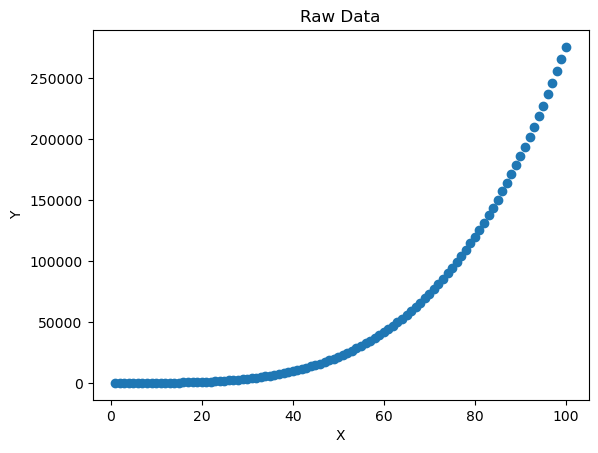

In [4]:
X = df[['X']]
y = df['Y']

plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Raw Data')
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

## Baseline: Simple Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Linear Regression R2 score:", r2_score(y_test, y_pred_lr))

Linear Regression R2 score: 0.7687865230647417


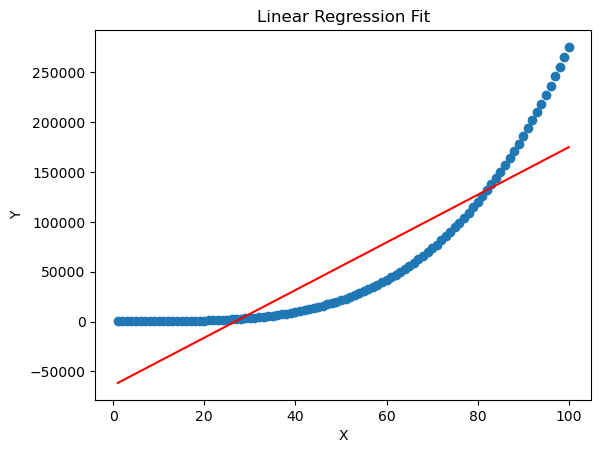

In [7]:
X_sorted = X.sort_values('X')
plt.scatter(X, y)
plt.plot(X_sorted, lr.predict(X_sorted), color='r')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.show()

## Polynomial Regression - Compare degrees

In [8]:
results = {}

for degree in range(1, 7):
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    X_train_trans = poly.fit_transform(X_train)
    X_test_trans = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_trans, y_train)

    y_pred = model.predict(X_test_trans)
    score = r2_score(y_test, y_pred)
    results[degree] = score
    print(f"Degree {degree}: R2 score = {score:.4f}")

Degree 1: R2 score = 0.7688
Degree 2: R2 score = 0.9782
Degree 3: R2 score = 0.9997
Degree 4: R2 score = 1.0000
Degree 5: R2 score = 1.0000
Degree 6: R2 score = 1.0000


In [9]:
best_degree = max(results, key=results.get)
print(f"Best degree: {best_degree} with R2 = {results[best_degree]:.4f}")

Best degree: 4 with R2 = 1.0000


## Final Model - Train with best degree on full transformed data

In [10]:
poly = PolynomialFeatures(degree=best_degree, include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

final_model = LinearRegression()
final_model.fit(X_train_trans, y_train)

y_pred_final = final_model.predict(X_test_trans)
print("Final R2 score:", r2_score(y_test, y_pred_final))

Final R2 score: 0.9999999999999999


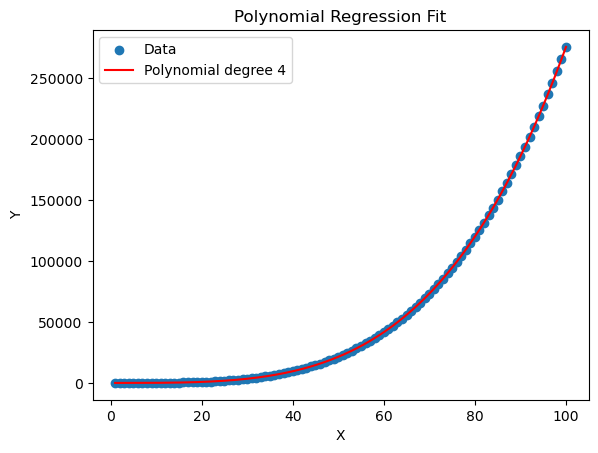

In [11]:
# Plot smooth curve over the full X range
X_range = np.linspace(X['X'].min(), X['X'].max(), 200).reshape(-1, 1)
X_range_df = pd.DataFrame(X_range, columns=['X'])
X_range_trans = poly.transform(X_range_df)
y_range_pred = final_model.predict(X_range_trans)

plt.scatter(X, y, label='Data')
plt.plot(X_range, y_range_pred, color='r', label=f'Polynomial degree {best_degree}')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()

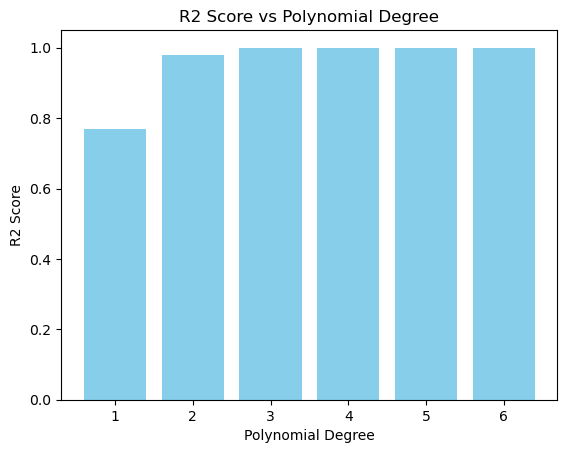

In [12]:
# Compare R2 scores across degrees as a bar chart
plt.bar(results.keys(), results.values(), color='skyblue')
plt.xlabel('Polynomial Degree')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Polynomial Degree')
plt.show()

In [13]:
# Final model coefficients and intercept
print("Intercept:", final_model.intercept_)
print("Coefficients:", final_model.coef_)

Intercept: 99.99861011614848
Coefficients: [ 0.00000000e+00  2.99996372e+00 -4.99998712e-01  7.99999839e-02
  2.00000007e-03]
